In [2]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_acf0e15c11aa92b3967f19efa54f8f67"

In [3]:
!kaggle competitions files -c digit-recognizer

name                         size  creationDate                
---------------------  ----------  --------------------------  
sample_submission.csv      240909  2019-12-11 20:00:27.210000  
test.csv                 51118296  2019-12-11 20:00:30.137000  
train.csv                76775041  2019-12-11 20:00:30.885000  


In [10]:
!kaggle competitions download -c digit-recognizer


  0%|          | 0.00/15.3M [00:00<?, ?B/s]
  7%|6         | 1.00M/15.3M [00:01<00:19, 780kB/s]
 13%|#3        | 2.00M/15.3M [00:01<00:09, 1.50MB/s]
 20%|#9        | 3.00M/15.3M [00:01<00:05, 2.36MB/s]
 26%|##6       | 4.00M/15.3M [00:01<00:03, 3.33MB/s]
 33%|###2      | 5.00M/15.3M [00:01<00:02, 4.26MB/s]
 46%|####5     | 7.00M/15.3M [00:02<00:01, 5.55MB/s]
 59%|#####8    | 9.00M/15.3M [00:02<00:00, 7.27MB/s]
 72%|#######1  | 11.0M/15.3M [00:02<00:00, 8.50MB/s]
 78%|#######8  | 12.0M/15.3M [00:02<00:00, 7.82MB/s]
 91%|#########1| 14.0M/15.3M [00:02<00:00, 9.22MB/s]
100%|##########| 15.3M/15.3M [00:03<00:00, 5.32MB/s]


In [11]:
import os
os.listdir()

['.anaconda',
 '.bash_history',
 '.conda',
 '.condarc',
 '.continuum',
 '.git',
 '.gitconfig',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.kaggle',
 '.lesshst',
 '.matplotlib',
 '.spyder-py3',
 '.virtual_documents',
 '.vscode',
 '.vscode-shared',
 '50_Startups.csv',
 'AB_NYC_2019.csv',
 'Airbnb Data analysis.ipynb',
 'anaconda3',
 'Analyse columns.ipynb',
 'Analysing Age & Marital status.ipynb',
 'Analysing gender.ipynb',
 'ann_model.py',
 'AppData',
 'Application Data',
 'Apply CCA.ipynb',
 'array.py',
 'basket_size_analysis.png',
 'BlackFriday.csv',
 'cars.csv',
 'category_sales.png',
 'Combining Age & Marital Status.ipynb',
 'Contacts',
 'Cookies',
 'Customer behavior analysis using Python.ipynb',
 'customer_shopping_behavior.csv',
 'Data Analysis using Group by.ipynb',
 'Data Analysis with python.ipynb',
 'data_science_job.csv',
 'digit-recognizer.zip',
 'Documents',
 'Downloads',
 'EDA Bivariate Analysis .ipynb',
 'EDA Titanic Data.ipynb',
 'Favorites',
 'Featu

In [4]:
import zipfile

with zipfile.ZipFile("digit-recognizer.zip", "r") as zip_ref:
    zip_ref.extractall("digit_data")

In [5]:
import os

os.listdir("digit_data")

['sample_submission.csv', 'test.csv', 'train.csv']

In [6]:
import pandas as pd

train = pd.read_csv("digit_data/train.csv")
test = pd.read_csv("digit_data/test.csv")

print(train.shape)
print(test.shape)

(42000, 785)
(28000, 784)


In [7]:
train.shape

(42000, 785)

In [8]:
train.head(10)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
train.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
6342,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
import matplotlib.pyplot as plt

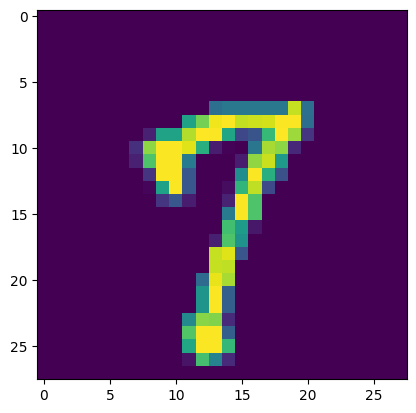

In [11]:
plt.imshow(train.iloc[19885,1:].values.reshape(28,28))

In [12]:
x = train.iloc[:,1:]
y = train.iloc[:,0]

In [13]:
x

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [15]:
x_train.shape

(33600, 784)

In [16]:
from sklearn.neighbors import KNeighborsClassifier

In [17]:
KNN = KNeighborsClassifier()

In [18]:
KNN.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [19]:
import time
start = time.time()
y_pred = KNN.predict(x_test)
print(time.time() - start)

16.026652097702026


In [22]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9648809523809524

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [24]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [25]:
# PCA :- Principal Component Analysis
from sklearn.decomposition import PCA
pca = PCA(n_components = 200)

In [26]:
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [27]:
x_train_trf.shape

(33600, 200)

In [28]:
KNN = KNeighborsClassifier()

In [29]:
KNN.fit(x_train_trf,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [30]:
y_pred = KNN.predict(x_test_trf)

In [31]:
accuracy_score(y_test,y_pred)

0.9507142857142857

In [ ]:
for i in range(1,785):
    pca = PCA(n_components= i)
    x_train_trf = pca.fit_transform(x_train)
    
    x_test_trf = pca.transform(x_test)

    kNN = KNeighborsClassifier()
    
    KNN.fit(x_train_trf,y_train)
    
    y_pred = KNN.predict(x_test_trf)

    print(accuracy_score(y_test,y_pred))

BY using this code iterate one by one and calculate accuracy. we take only those components those cover 90% - 95% data spread

In [32]:
## Transforming to a 2D coordinate system
pca = PCA(n_components=2)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [33]:
x_train_trf

array([[-2.71863253, -0.48982409],
       [-0.67698015, -6.75362491],
       [-3.03323281,  6.50981624],
       ...,
       [ 2.14883643,  0.78079444],
       [ 1.05957006,  0.94767312],
       [17.70258446,  1.96188185]])

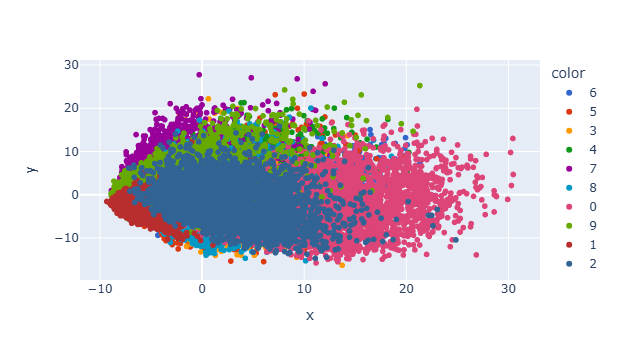

In [38]:
import plotly.express as px

y_train_trf = y_train.astype(str)

fig = px.scatter(
    x = x_train_trf[:, 0],  # First Principal Component
    y = x_train_trf[:, 1],  # Second Principal Component
    color = y_train_trf,
    color_discrete_sequence = px.colors.qualitative.G10
)

fig.show()

In [39]:
## Transforming in 3D
pca = PCA(n_components = 3)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [40]:
x_train_trf

array([[-2.71863253, -0.48982409,  1.1354966 ],
       [-0.67698015, -6.75362491, -2.33590139],
       [-3.03323281,  6.50981624,  7.49182983],
       ...,
       [ 2.14883643,  0.78079444, -0.74738774],
       [ 1.05957006,  0.94767312,  3.94973114],
       [17.70258446,  1.96188185, -4.94352837]])

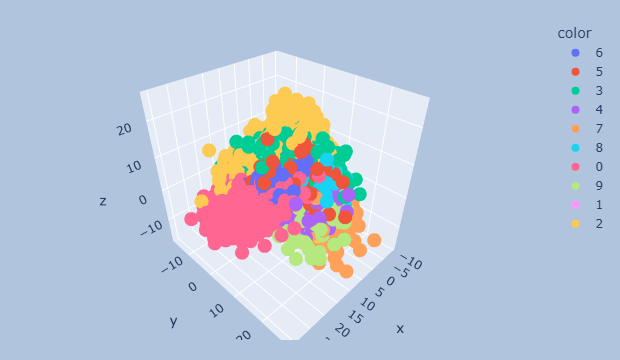

In [43]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(x=x_train_trf[:,0], y=x_train_trf[:,1], z=x_train_trf[:,2],
              color=y_train_trf)
fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20),
    paper_bgcolor="LightSteelBlue",
)
fig.show()

In [44]:
pca.explained_variance_
# Eigen values

array([40.67111198, 29.17023401, 26.74459621])

In [45]:
# Eigen vectors
pca.components_.shape

(3, 784)

In [46]:
pca.explained_variance_ratio_

array([0.05785192, 0.0414927 , 0.03804239])

In [48]:
pca = PCA(n_components=None)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [49]:
pca.explained_variance_.shape

(784,)

In [50]:
pca.components_.shape

(784, 784)

In [52]:
import numpy as np
np.cumsum(pca.explained_variance_ratio_)

array([0.05785192, 0.09934462, 0.13738701, 0.16704964, 0.19286525,
       0.21541506, 0.23514574, 0.25289854, 0.26858504, 0.28294568,
       0.29664822, 0.30892077, 0.32038989, 0.33162017, 0.34220546,
       0.35240477, 0.36198153, 0.37140862, 0.38053351, 0.38943521,
       0.39783462, 0.40603525, 0.41388828, 0.42145568, 0.42882829,
       0.43584714, 0.44282633, 0.44953738, 0.45593583, 0.4622392 ,
       0.46839271, 0.4744166 , 0.48025334, 0.48603881, 0.49176214,
       0.49722614, 0.50265822, 0.50793994, 0.51307376, 0.51801392,
       0.52289063, 0.52771041, 0.53239246, 0.53698588, 0.54156249,
       0.54605468, 0.5505015 , 0.55491691, 0.55926803, 0.56358836,
       0.56780645, 0.57198888, 0.57606882, 0.58008887, 0.58407223,
       0.58801822, 0.59188694, 0.59571889, 0.59948441, 0.60322635,
       0.60687487, 0.6104829 , 0.61402176, 0.61750117, 0.62094441,
       0.62432378, 0.62767368, 0.63099377, 0.63426257, 0.63746765,
       0.64065542, 0.64376931, 0.64686564, 0.64992395, 0.65296

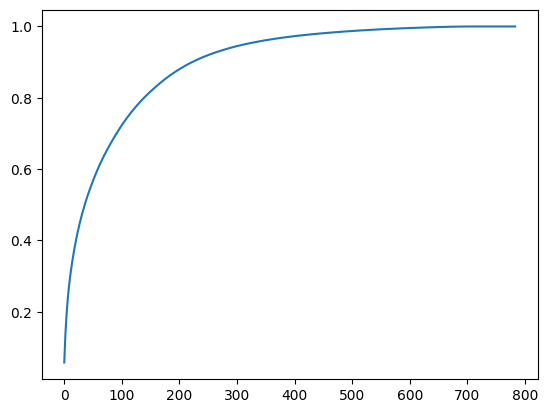

In [53]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))